# 50-Run Stability Analysis: SG-KAN(SWIM), SG-KAN(Random)

Standalone notebook to load the 50-run CSV results for all four models at each test function's best configuration, and compare their RMSE distributions via summary statistics and boxplots.

**Expects the following files in the working directory** (or update `DATA_DIR` below),
one per test function N = 1, 2, 3, 4, 5:
- `tf{N}_sgkan_50_run_results.csv` (SG-KAN SWIM)
- `tf{N}_sgkan_random_50_run_results.csv` (SG-KAN Random)

Each CSV is expected to have columns:
`seed, train_mae, train_rmse, train_inference_time_secs, test_mae, test_rmse, test_inference_time_secs, fit_time_secs`


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

pd.set_option("display.precision", 6)

DATA_DIR = "data"  # change if your CSVs live elsewhere
TEST_FUNCTIONS = ["tf1", "tf2", "tf3", "tf4", "tf5"]

# model key -> (display label, filename suffix, plot color)
MODELS = {
    "swim":   ("SG-KAN (SWIM)",   "sgkan_50_run_results.csv",         "#1f77b4"),
    "random": ("SG-KAN (Random)", "sgkan_random_50_run_results.csv",  "#ff7f0e"),
}


## Load all 50-run CSVs

Loads whatever files are present; missing model/test-function combinations
are skipped (printed as a note) rather than causing an error.

In [2]:
results = {tf: {} for tf in TEST_FUNCTIONS}

for tf in TEST_FUNCTIONS:
    for model_key, (label, suffix, _) in MODELS.items():
        path = f"{DATA_DIR}/{tf}_{suffix}"
        if os.path.exists(path):
            results[tf][model_key] = pd.read_csv(path)
        else:
            print(f"[skip] {tf.upper()} {label}: file not found at {path}")

print()
for tf in TEST_FUNCTIONS:
    found = ", ".join(MODELS[k][0] for k in results[tf])
    print(f"{tf.upper()}: {found if found else '(none found)'}")



TF1: SG-KAN (SWIM), SG-KAN (Random), HKAN, KAN
TF2: SG-KAN (SWIM), SG-KAN (Random), HKAN, KAN
TF3: SG-KAN (SWIM), SG-KAN (Random), HKAN, KAN
TF4: SG-KAN (SWIM), SG-KAN (Random), HKAN, KAN
TF5: SG-KAN (SWIM), SG-KAN (Random), HKAN, KAN


## Summary statistics

For each test function, split (train/test), and available model, compute
median, IQR, std, skewness, min, and max. Also flags the median winner and
the stability (lowest std) winner among whichever models are present.

In [3]:
def summarize(df, col):
    vals = df[col].values
    return {
        "median": np.median(vals),
        "iqr": np.percentile(vals, 75) - np.percentile(vals, 25),
        "std": vals.std(),
        "skew": skew(vals),
        "min": vals.min(),
        "max": vals.max(),
    }


def build_summary_table(results, metric="rmse"):
    rows = []
    for tf in TEST_FUNCTIONS:
        for split in ["train", "test"]:
            col = f"{split}_{metric}"
            available = {k: df for k, df in results[tf].items() if col in df.columns}
            if not available:
                continue

            stats = {k: summarize(df, col) for k, df in available.items()}
            median_winner = min(stats, key=lambda k: stats[k]["median"])
            stability_winner = min(stats, key=lambda k: stats[k]["std"])

            row = {"test_function": tf.upper(), "split": split}
            for k in MODELS:
                if k in stats:
                    row[f"{k}_median"] = stats[k]["median"]
                    row[f"{k}_std"] = stats[k]["std"]
            row["median_winner"] = MODELS[median_winner][0]
            row["stability_winner"] = MODELS[stability_winner][0]
            rows.append(row)
    return pd.DataFrame(rows)


summary_df = build_summary_table(results, metric="rmse")
summary_df.to_csv("data/all_models_stability_summary_df.csv")


/var/folders/5g/94j7hdwx0k5fpcdmgs_76q4c0000gn/T/ipykernel_85777/3726159291.py:7: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": skew(vals),


In [4]:
# Quick tally: how often does each model win on median vs. on stability?
print("Median RMSE winner counts:")
print(summary_df["median_winner"].value_counts())
print("\nStability (lower std) winner counts:")
print(summary_df["stability_winner"].value_counts())


Median RMSE winner counts:
median_winner
HKAN               9
SG-KAN (Random)    1
Name: count, dtype: int64

Stability (lower std) winner counts:
stability_winner
HKAN    8
KAN     2
Name: count, dtype: int64


## Boxplots: all available models per test function

One figure per test function, with train and test RMSE side by side
(log scale, since values span many orders of magnitude). Mean is shown
as a white diamond marker to highlight skewness (mean far from median
indicates a heavy tail / occasional extreme runs). Only models with data
for that test function are plotted.

In [5]:
def plot_models_boxplots(results, tf, metric="rmse", save=True,
                          save_dir="static", save_path=None):
    """Side-by-side boxplots comparing all available models' distributions
    across 50 seeds, for train and test splits."""
    available_keys = [k for k in MODELS if k in results[tf]]
    if not available_keys:
        print(f"[skip] no data for {tf.upper()}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(3 * len(available_keys) + 3, 6))

    for ax, split in zip(axes, ["train", "test"]):
        col = f"{split}_{metric}"
        data, labels, colors = [], [], []
        for k in available_keys:
            df = results[tf][k]
            if col not in df.columns:
                continue
            data.append(df[col].values)
            labels.append(MODELS[k][0].replace(" (", "\n("))
            colors.append(MODELS[k][2])

        bp = ax.boxplot(
            data,
            tick_labels=labels,
            patch_artist=True,
            showmeans=True,
            meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='black',
               markersize=8, markeredgewidth=1.2, zorder=5),
        )
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)

        ax.set_yscale('log')
        ax.set_ylabel(f'{metric.upper()} (log scale)', fontsize=12)
        ax.set_title(f'{split.capitalize()} {metric.upper()}', fontsize=13)
        ax.grid(True, alpha=0.3, axis='y')
        ax.tick_params(axis='both', labelsize=10)

    fig.suptitle(f'{tf.upper()} — model comparison, 50 runs', fontsize=15)
    plt.tight_layout()

    if save:
        os.makedirs(save_dir, exist_ok=True)
        out_path = save_path or os.path.join(save_dir, f"{tf}_all_models_boxplot.png")
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        print(f"saved to {out_path}")

    plt.show()


saved to static/tf1_all_models_boxplot.png


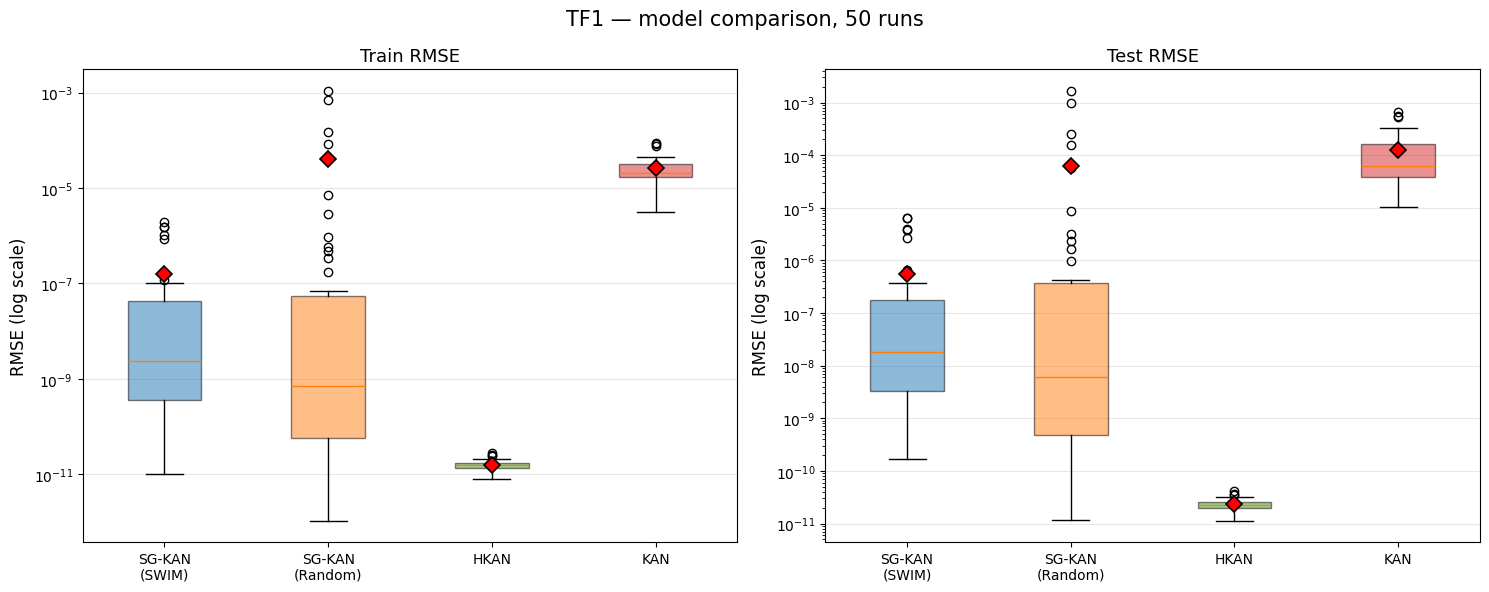

saved to static/tf2_all_models_boxplot.png


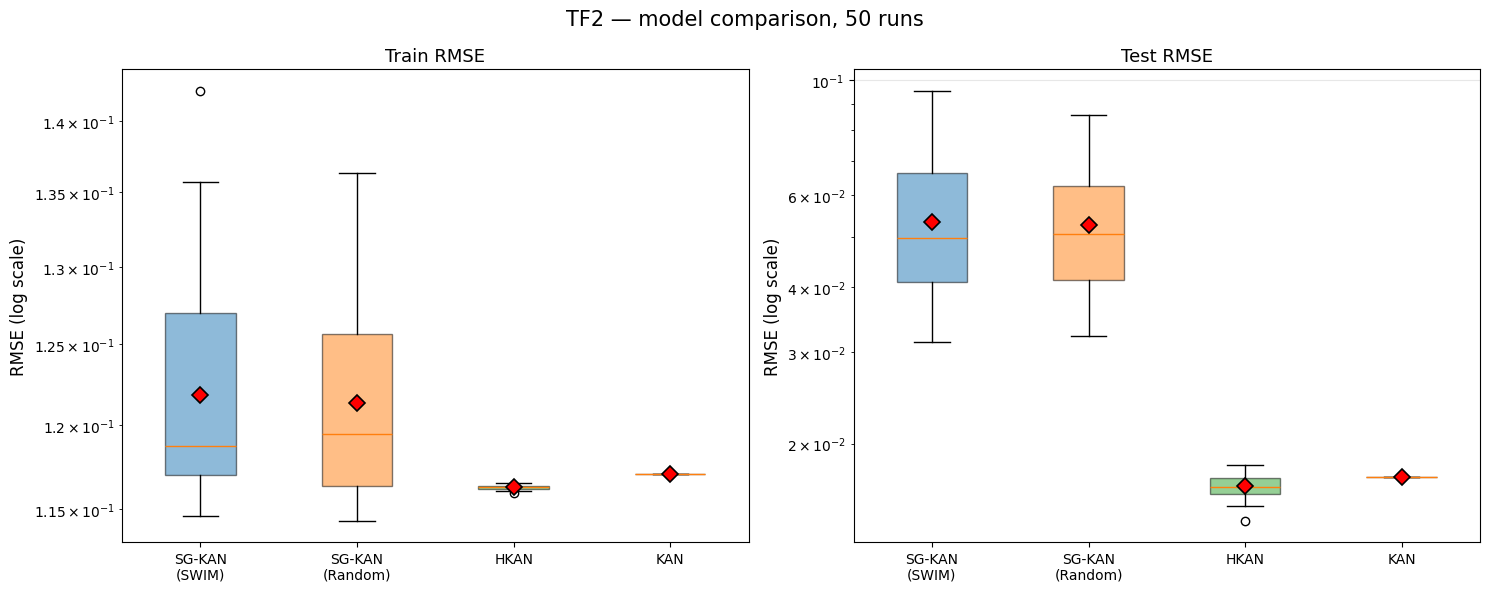

saved to static/tf3_all_models_boxplot.png


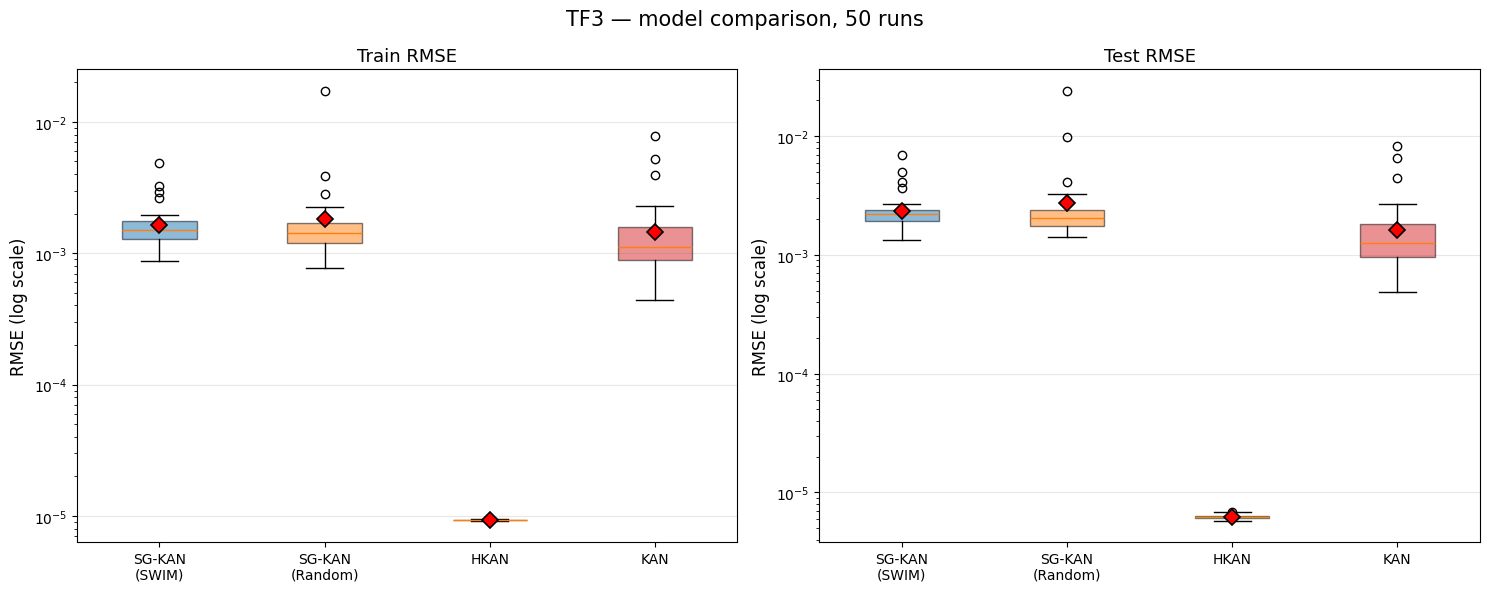

saved to static/tf4_all_models_boxplot.png


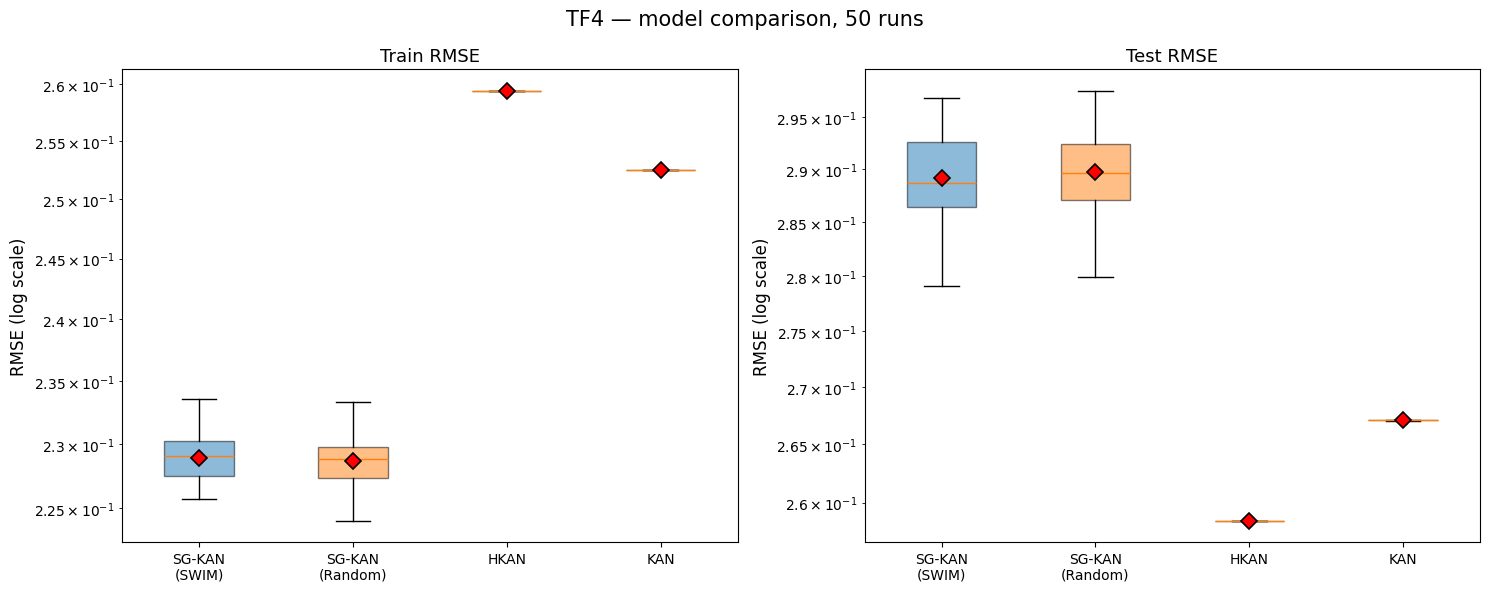

saved to static/tf5_all_models_boxplot.png


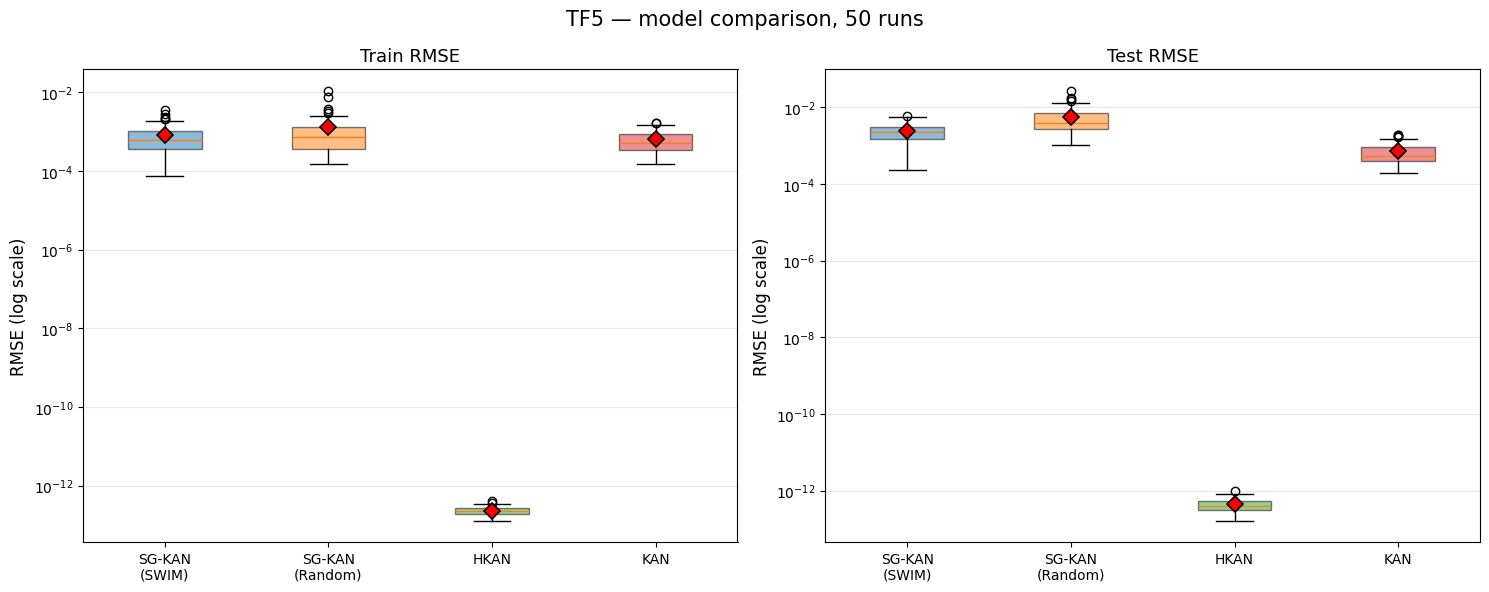

In [6]:
for tf in TEST_FUNCTIONS:
    plot_models_boxplots(results, tf, metric="rmse")
